# Experiment 1: Baseline Diffusion
**Drug Modeled:** Gefitinib

**Condition Tested:** Diffusion profiles with varying changes: baseline, time variation, diffusion coefficient variation

**Research Question:** How does gefitinib diffuse through tumor tissue?

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Effective diffusion coefficient for gefitinib in tumor tissue
# Literature-derived range for small-molecule transport in solid tumors:
# 10^-7 to 10^-6 cm^2 /s
# Baseline value chosen for simulation
D = 5e-7            # cm^2 /s

# Normalized source concentration
# Relative concentration used to study spatial gradients
C0 = 1.0            # arbitrary units

# Tissue depth range
# 0-2 mm into tumor tissue
x = np.linspace(0, 0.2, 1000)       # cm

# Single time point
# 1 hour after drug exposure
t = 3600            # seconds

In [5]:
import numpy as np

# Analytical Solution to Fick's Second Law

# Fundamental solution of the 1D diffusion equation

# Represents spatial redistribution of drug from an initial source

normalization = 1 / np.sqrt(4 * np.pi * D * t)

# Gefitinib concentration profile as a function of depth

C = C0 * normalization * np.exp(-(x**2) / (4 * D * t))

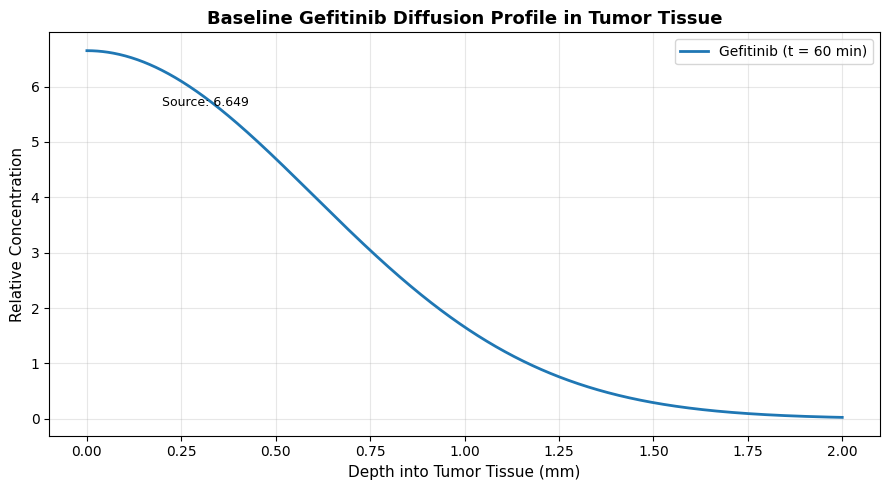

In [6]:
import os
os.makedirs('figures', exist_ok = True)

# Plot

fig, ax = plt.subplots(figsize = (9,5))

ax.plot(x * 10, C, linewidth = 2, label = 'Gefitinib (t = 60 min)')

# Labels and formatting
ax.set_title('Baseline Gefitinib Diffusion Profile in Tumor Tissue', 
                fontsize = 13, fontweight = 'bold')


ax.set_xlabel('Depth into Tumor Tissue (mm)', fontsize = 11)

ax.set_ylabel('Relative Concentration', fontsize = 11)

ax.legend(fontsize = 10)
ax.grid(True, alpha = 0.3)

# Annotate peak concentration

peak = C[0]

ax.annotate(f'Source: {peak:0.3f}', xy = (0, peak), xytext = (0.2, peak * 0.85), fontsize = 9)

plt.tight_layout()
plt.savefig('figures/exp01_baseline.png', dpi = 150)
plt.show()


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# Parameters

# Effective diffusion coefficient for gefitinib in tumor tissue
# Representative value within the literature range (~10^-7 to 10^-6 cm²/s)
D = 5e-7             # cm²/s

# Normalized source concentration
C0 = 1.0             # arbitrary units

# Tissue depth range
# 0–2 mm into tumor tissue
x = np.linspace(0, 0.2, 1000)    # cm

# Time points for diffusion evolution
times_min = [10, 30, 60, 120]    # minutes
times_sec = [t * 60 for t in times_min]

# Color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

In [8]:
# Analytical Solution Across Time Points 

profiles = []

for t in times_sec:

    normalization = 1 / np.sqrt(4 * np.pi * D * t)

    C = C0 * normalization * np.exp(-(x**2) / (4 * D * t))

    profiles.append(C)

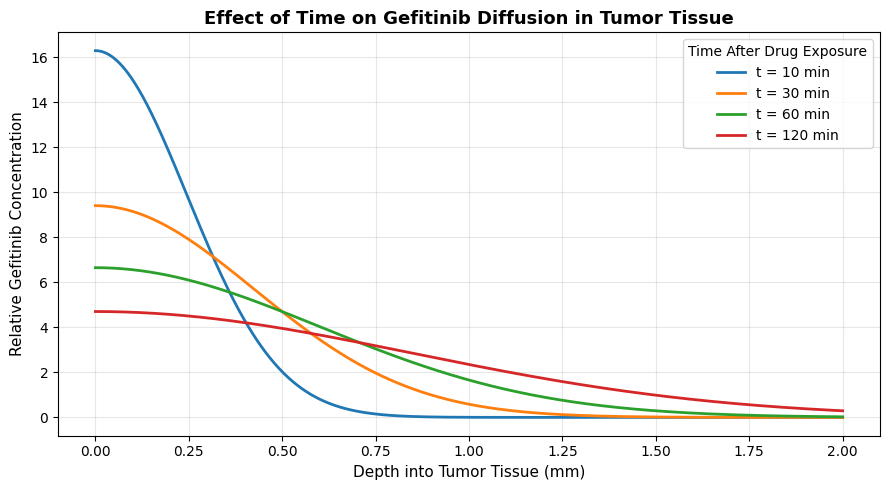

In [9]:
# Plot

fig, ax = plt.subplots(figsize=(9, 5))

for i, (C, t_min) in enumerate(zip(profiles, times_min)):
    ax.plot(x * 10, C, color=colors[i],
                linewidth=2, label=f't = {t_min} min')

ax.set_title('Effect of Time on Gefitinib Diffusion in Tumor Tissue', fontsize=13, fontweight='bold')

ax.set_xlabel('Depth into Tumor Tissue (mm)', fontsize=11)

ax.set_ylabel('Relative Gefitinib Concentration', fontsize=11)

ax.legend(fontsize=10, title='Time After Drug Exposure')

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/exp01_time_variation.png', dpi=150)
plt.show()